# Исследование ассемблерных оптимизаций на примере хэш-таблиц

## Подбор хэш-функции

Для начала нам нужно выбрать хэш функцию. Для этого мы построим хэш-таблицу на примерно 4957 элементов и будем класть в нее ~20000 слов. После этого посмотрим на распределение элементов по корзинам.

### Хэш функция - длина строки

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

df = pd.read_csv("hash_func_choose/test_hashes/result.csv",  sep=";")

df.head()

,hash_func,bucket,size
0,hash_length,0,0
1,hash_length,1,36
2,hash_length,2,139
3,hash_length,3,687
4,hash_length,4,2108


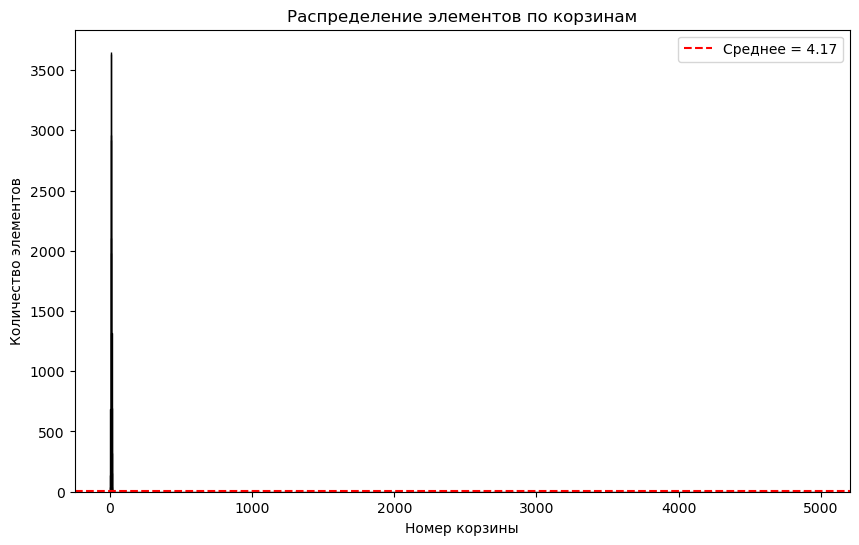

Среднее значение: 4.17
Дисперсия распределения: 11094.51
Стандартное отклонение: 105.33


In [18]:
filtered = df[df["hash_func"] == "hash_length"]

buckets = filtered["bucket"].astype(int)
counts = filtered["size"].astype(int)

mean_val = counts.mean()
variance = counts.var()
std = counts.std()

plt.figure(figsize=(10,6))
plt.bar(buckets, counts, color='black', edgecolor='black')
plt.axhline(mean_val, color='red', linestyle='--', label=f'Среднее = {mean_val:.2f}')
plt.xlabel("Номер корзины")
plt.ylabel("Количество элементов")
plt.title("Распределение элементов по корзинам")
plt.legend()
plt.show()

print(f"Среднее значение: {mean_val:.2f}")
print(f"Дисперсия распределения: {variance:.2f}")
print(f"Стандартное отклонение: {std:.2f}")

#### Посмотрим на график чуть ближе

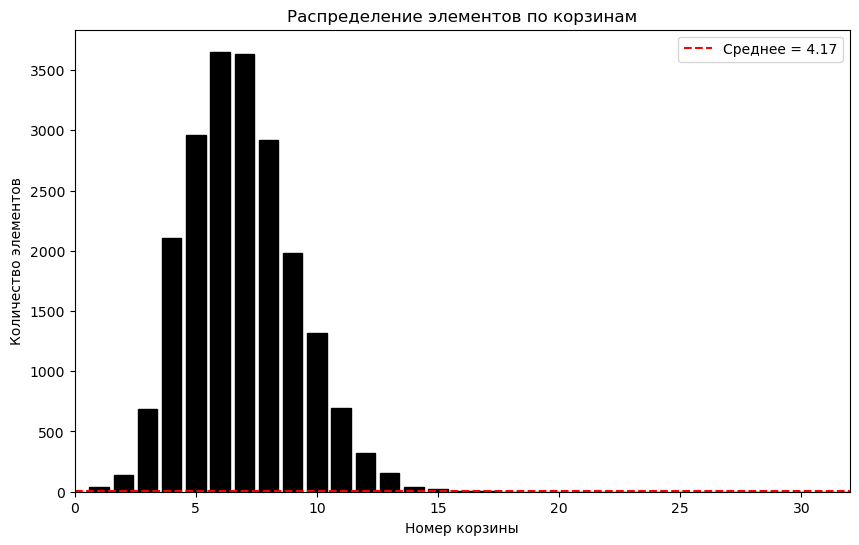

In [19]:
plt.figure(figsize=(10,6))
plt.bar(buckets, counts, color='black', edgecolor='black')
plt.axhline(mean_val, color='red', linestyle='--', label=f'Среднее = {mean_val:.2f}')
plt.xlabel("Номер корзины")
plt.ylabel("Количество элементов")
plt.title("Распределение элементов по корзинам")
plt.legend()

plt.xlim(0, 32)
plt.show()

### Хэш функция - первая буква слова

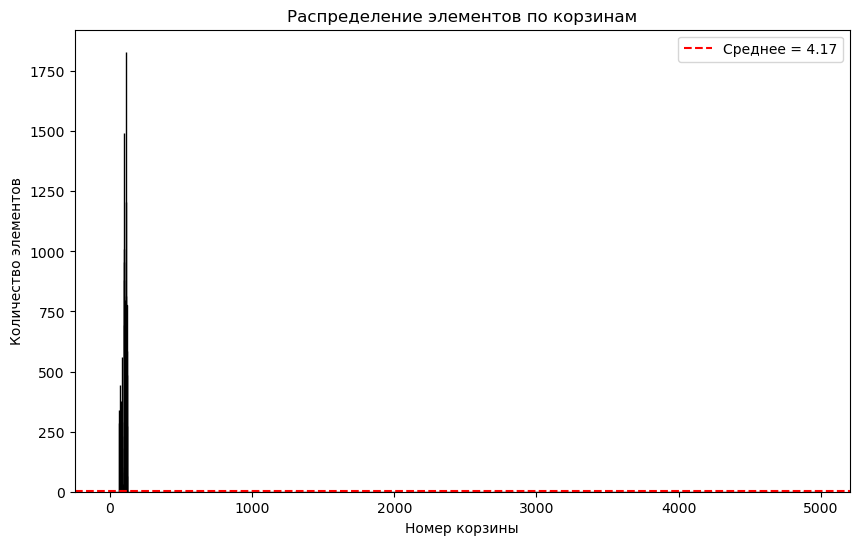

Среднее значение: 4.17
Дисперсия распределения: 3248.38
Стандартное отклонение: 56.99


In [20]:
filtered = df[df.iloc[:,0] == "hash_first_letter"]

buckets = filtered["bucket"].astype(int)
counts = filtered["size"].astype(int)

mean_val = counts.mean()
variance = counts.var()
std = counts.std()

plt.figure(figsize=(10,6))
plt.bar(buckets, counts, color='black', edgecolor='black')
plt.axhline(mean_val, color='red', linestyle='--', label=f'Среднее = {mean_val:.2f}')
plt.xlabel("Номер корзины")
plt.ylabel("Количество элементов")
plt.title("Распределение элементов по корзинам")
plt.legend()
plt.show()

print(f"Среднее значение: {mean_val:.2f}")
print(f"Дисперсия распределения: {variance:.2f}")
print(f"Стандартное отклонение: {std:.2f}")

#### Посмотрим на график чуть ближе

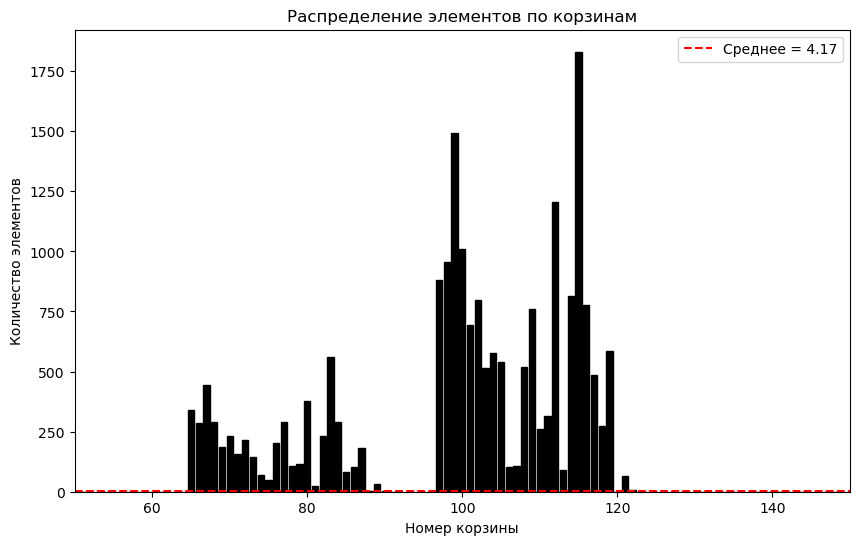

In [21]:
plt.figure(figsize=(10,6))
plt.bar(buckets, counts, color='black', edgecolor='black')
plt.axhline(mean_val, color='red', linestyle='--', label=f'Среднее = {mean_val:.2f}')
plt.xlabel("Номер корзины")
plt.ylabel("Количество элементов")
plt.title("Распределение элементов по корзинам")
plt.legend()

plt.xlim(50, 150)
plt.show()

### Хэш функция - сумма букв в слове

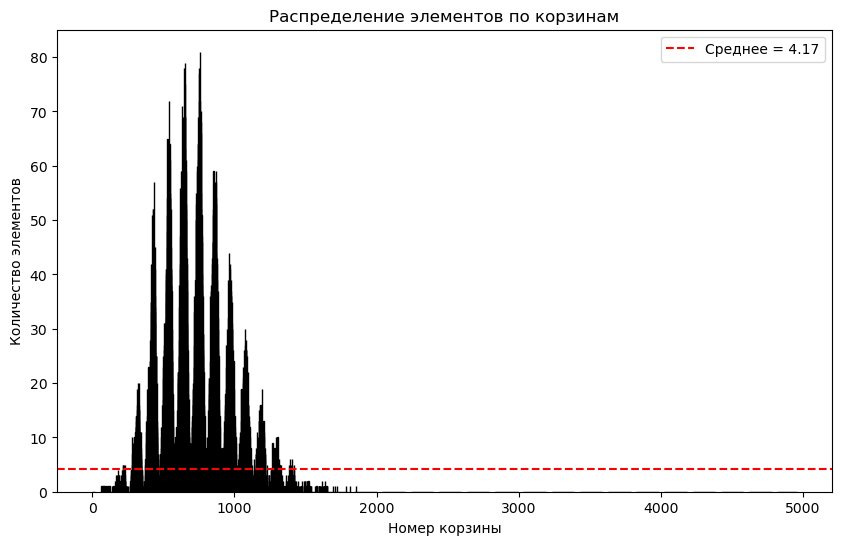

Среднее значение: 4.17
Дисперсия распределения: 131.95
Стандартное отклонение: 11.49


In [22]:
filtered = df[df.iloc[:,0] == "hash_sum_letters"]

buckets = filtered["bucket"].astype(int)
counts = filtered["size"].astype(int)

mean_val = counts.mean()
variance = counts.var()
std = counts.std()

plt.figure(figsize=(10,6))
plt.bar(buckets, counts, color='black', edgecolor='black')
plt.axhline(mean_val, color='red', linestyle='--', label=f'Среднее = {mean_val:.2f}')
plt.xlabel("Номер корзины")
plt.ylabel("Количество элементов")
plt.title("Распределение элементов по корзинам")
plt.legend()
plt.show()

print(f"Среднее значение: {mean_val:.2f}")
print(f"Дисперсия распределения: {variance:.2f}")
print(f"Стандартное отклонение: {std:.2f}")

#### Посмотрим на график чуть ближе

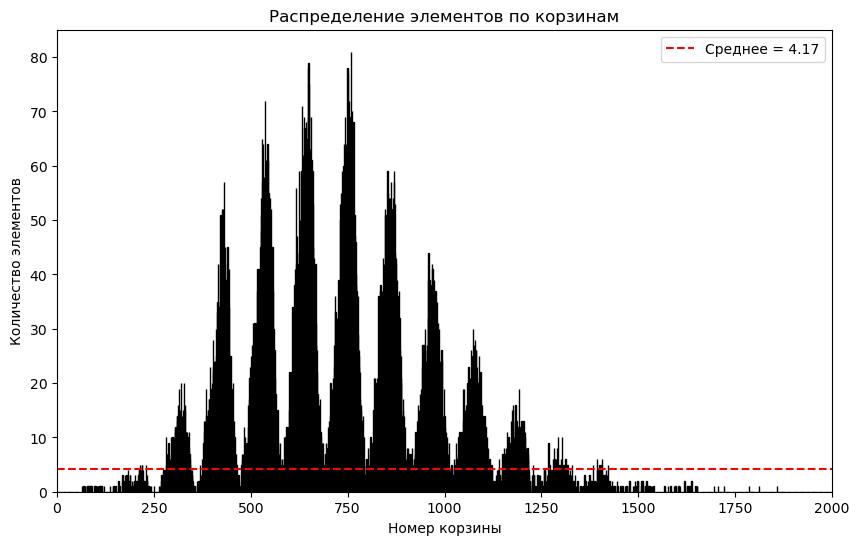

In [23]:
plt.figure(figsize=(10,6))
plt.bar(buckets, counts, color='black', edgecolor='black')
plt.axhline(mean_val, color='red', linestyle='--', label=f'Среднее = {mean_val:.2f}')
plt.xlabel("Номер корзины")
plt.ylabel("Количество элементов")
plt.title("Распределение элементов по корзинам")
plt.legend()

plt.xlim(0, 2000)
plt.show()

### Хэш функция - полиномиальный хэш

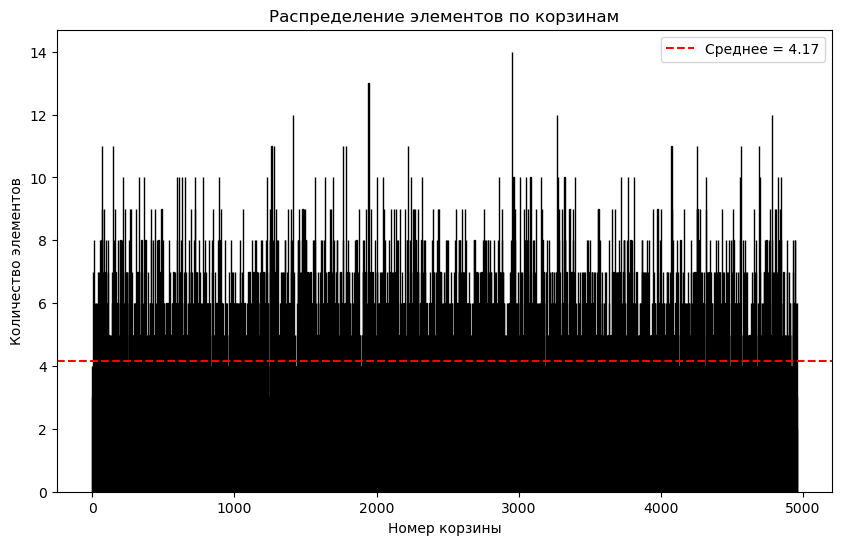

Среднее значение: 4.17
Дисперсия распределения: 4.11
Стандартное отклонение: 2.03


In [24]:
filtered = df[df.iloc[:,0] == "hash_polynomial"]

buckets = filtered["bucket"].astype(int)
counts = filtered["size"].astype(int)

mean_val = counts.mean()
variance = counts.var()
std = counts.std()

plt.figure(figsize=(10,6))
plt.bar(buckets, counts, color='black', edgecolor='black')
plt.axhline(mean_val, color='red', linestyle='--', label=f'Среднее = {mean_val:.2f}')
plt.xlabel("Номер корзины")
plt.ylabel("Количество элементов")
plt.title("Распределение элементов по корзинам")
plt.legend()
plt.show()

print(f"Среднее значение: {mean_val:.2f}")
print(f"Дисперсия распределения: {variance:.2f}")
print(f"Стандартное отклонение: {std:.2f}")

### Хэш функция - crc32

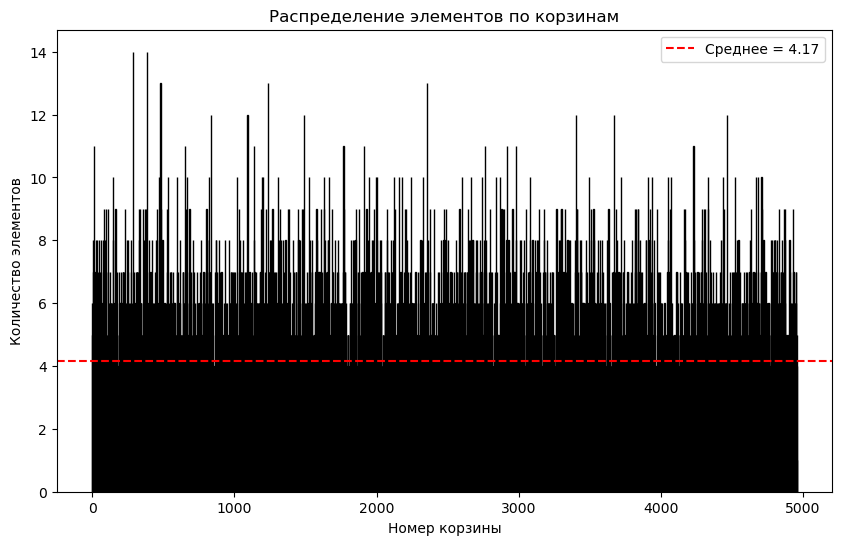

Среднее значение: 4.17
Дисперсия распределения: 4.17
Стандартное отклонение: 2.04


In [25]:
filtered = df[df.iloc[:,0] == "hash_crc32"]

buckets = filtered["bucket"].astype(int)
counts = filtered["size"].astype(int)

mean_val = counts.mean()
variance = counts.var()
std = counts.std()

plt.figure(figsize=(10,6))
plt.bar(buckets, counts, color='black', edgecolor='black')
plt.axhline(mean_val, color='red', linestyle='--', label=f'Среднее = {mean_val:.2f}')
plt.xlabel("Номер корзины")
plt.ylabel("Количество элементов")
plt.title("Распределение элементов по корзинам")
plt.legend()
plt.show()

print(f"Среднее значение: {mean_val:.2f}")
print(f"Дисперсия распределения: {variance:.2f}")
print(f"Стандартное отклонение: {std:.2f}")

### Хэш функция - Jenkins hash function

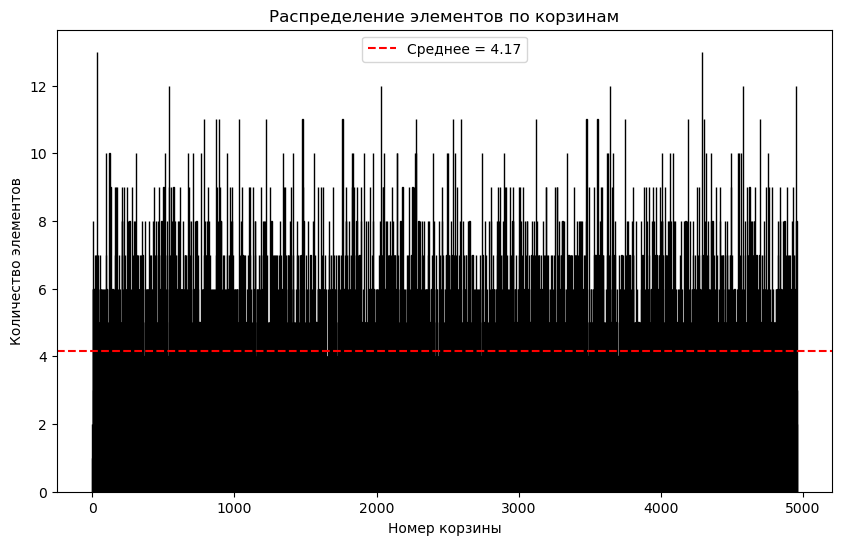

Среднее значение: 4.17
Дисперсия распределения: 4.21
Стандартное отклонение: 2.05


In [26]:
filtered = df[df.iloc[:,0] == "hash_jenkins_one_at_a_time32"]

buckets = filtered["bucket"].astype(int)
counts = filtered["size"].astype(int)

mean_val = counts.mean()
variance = counts.var()
std = counts.std()

plt.figure(figsize=(10,6))
plt.bar(buckets, counts, color='black', edgecolor='black')
plt.axhline(mean_val, color='red', linestyle='--', label=f'Среднее = {mean_val:.2f}')
plt.xlabel("Номер корзины")
plt.ylabel("Количество элементов")
plt.title("Распределение элементов по корзинам")
plt.legend()
plt.show()

print(f"Среднее значение: {mean_val:.2f}")
print(f"Дисперсия распределения: {variance:.2f}")
print(f"Стандартное отклонение: {std:.2f}")

### Хэш функция - PJW hash / ELF hash

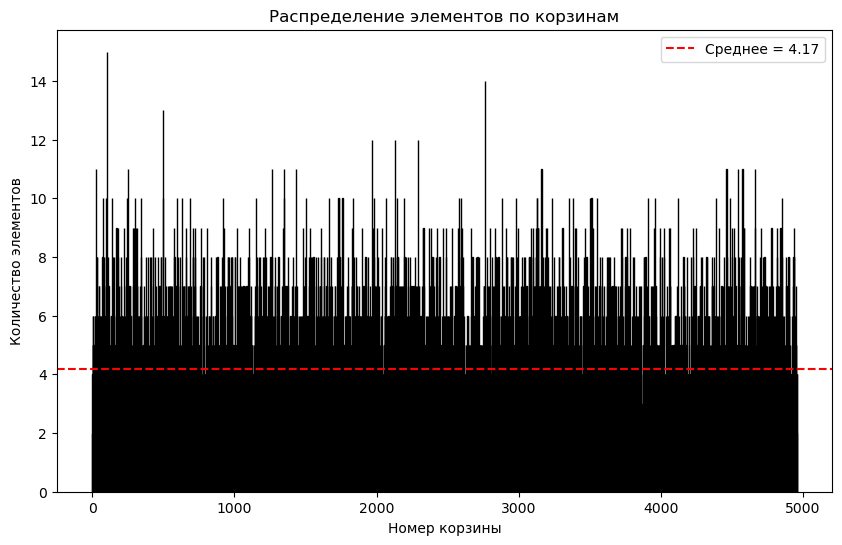

Среднее значение: 4.17
Дисперсия распределения: 4.18
Стандартное отклонение: 2.04


In [27]:
filtered = df[df.iloc[:,0] == "elf_hash"]

buckets = filtered["bucket"].astype(int)
counts = filtered["size"].astype(int)

mean_val = counts.mean()
variance = counts.var()
std = counts.std()

plt.figure(figsize=(10,6))
plt.bar(buckets, counts, color='black', edgecolor='black')
plt.axhline(mean_val, color='red', linestyle='--', label=f'Среднее = {mean_val:.2f}')
plt.xlabel("Номер корзины")
plt.ylabel("Количество элементов")
plt.title("Распределение элементов по корзинам")
plt.legend()
plt.show()

print(f"Среднее значение: {mean_val:.2f}")
print(f"Дисперсия распределения: {variance:.2f}")
print(f"Стандартное отклонение: {std:.2f}")

### Хэш функция - FNV1 hash

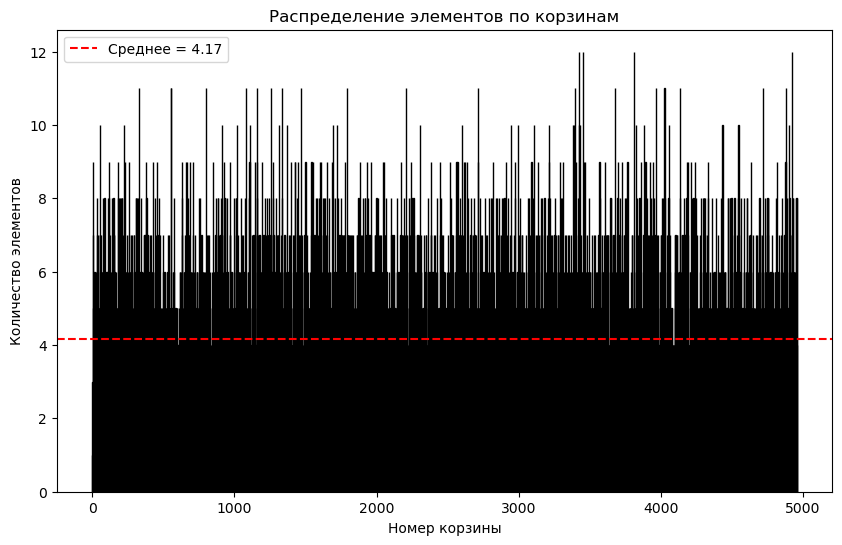

Среднее значение: 4.17
Дисперсия распределения: 4.13
Стандартное отклонение: 2.03


In [28]:
filtered = df[df.iloc[:,0] == "fnv1a_hash"]

buckets = filtered["bucket"].astype(int)
counts = filtered["size"].astype(int)

mean_val = counts.mean()
variance = counts.var()
std = counts.std()

plt.figure(figsize=(10,6))
plt.bar(buckets, counts, color='black', edgecolor='black')
plt.axhline(mean_val, color='red', linestyle='--', label=f'Среднее = {mean_val:.2f}')
plt.xlabel("Номер корзины")
plt.ylabel("Количество элементов")
plt.title("Распределение элементов по корзинам")
plt.legend()
plt.show()

print(f"Среднее значение: {mean_val:.2f}")
print(f"Дисперсия распределения: {variance:.2f}")
print(f"Стандартное отклонение: {std:.2f}")

### Хэш функция - Murmur3Hash

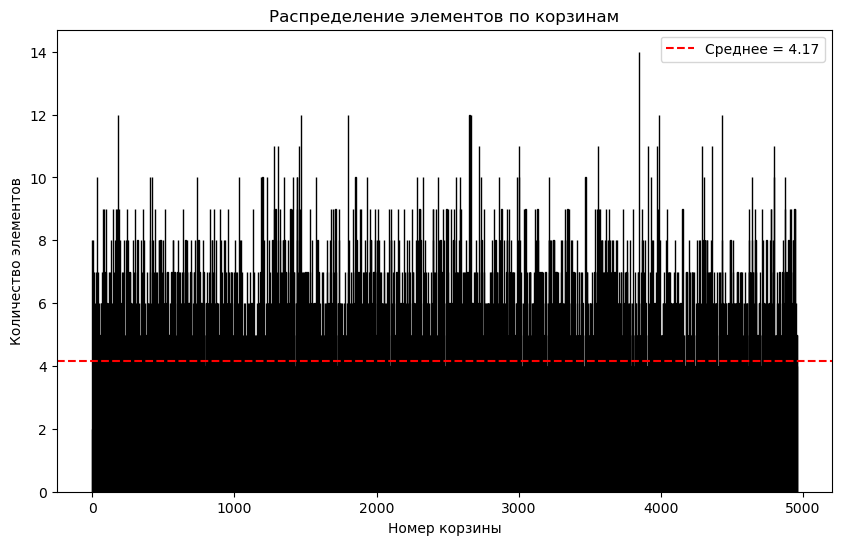

Среднее значение: 4.17
Дисперсия распределения: 4.16
Стандартное отклонение: 2.04


In [29]:
filtered = df[df.iloc[:,0] == "murmur3_hash"]

buckets = filtered["bucket"].astype(int)
counts = filtered["size"].astype(int)

mean_val = counts.mean()
variance = counts.var()
std = counts.std()

plt.figure(figsize=(10,6))
plt.bar(buckets, counts, color='black', edgecolor='black')
plt.axhline(mean_val, color='red', linestyle='--', label=f'Среднее = {mean_val:.2f}')
plt.xlabel("Номер корзины")
plt.ylabel("Количество элементов")
plt.title("Распределение элементов по корзинам")
plt.legend()
plt.show()

print(f"Среднее значение: {mean_val:.2f}")
print(f"Дисперсия распределения: {variance:.2f}")
print(f"Стандартное отклонение: {std:.2f}")

### Сравнение всех хэш функций

| Хэш-функция | Дисперсия количества элементов |
|--------|------|
| hash_length     | 11094.51  |
| hash_first_letter      | 3248.38   |
| hash_sum_letters      | 131.95 |
| hash_polynomial      | 4.11  |
| hash_crc32     | 4.17 |
| hash_jenkins_one_at_a_time32      | 4.21 |
| elf_hash     | 4.18 |
| fnv1a_hash      | 4.13 |
| murmur3_hash      | 4.16 |

Лучше всего себя показали хэш-функция hash_polynomial, поэтому для дальнейших рассчетов будем брать ее.

# Оптимизация хэш таблиц

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm


In [3]:
df = pd.read_csv("results.csv", header=None, sep=";")

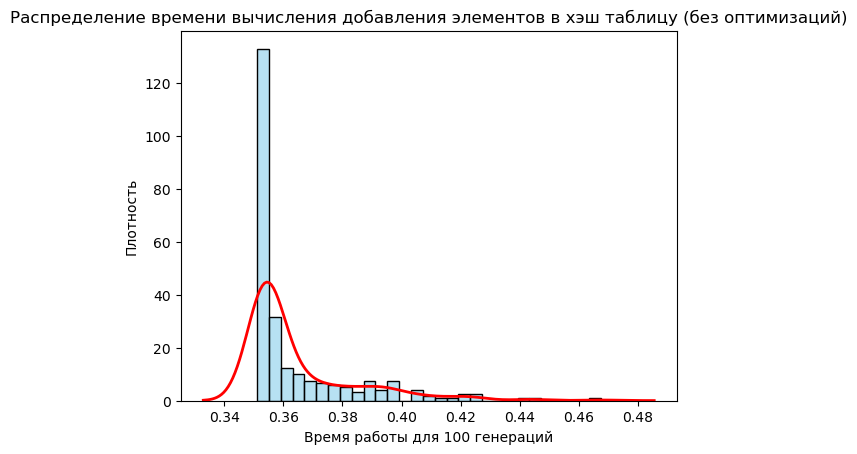

In [8]:
filtered = df[df.iloc[:,0] == "opt0"]

sns.histplot(
    data=filtered,
    x=filtered.iloc[:,1],
    bins="auto",
    stat="density",
    color="skyblue",
    alpha=0.6,
)

sns.kdeplot(
    data=filtered,
    x=filtered.iloc[:,1],
    color="red",
    linewidth=2
)

plt.xlabel("Время работы для 100 генераций")
plt.ylabel("Плотность")
plt.title("Распределение времени вычисления добавления элементов в хэш таблицу (без оптимизаций)")
plt.show()

In [9]:
filtered.describe()

,1
count,300.000000
mean,0.364244
std,0.018958
min,0.351059
25%,0.353415
50%,0.354812
75%,0.367020
max,0.467336


In [ ]:
mean = np.mean(filtered.iloc[:,1])
std = np.std(filtered.iloc[:,1], ddof=1)
n = len(filtered.iloc[:,1])

alpha = 0.05 
z = norm.ppf(1 - alpha/2)

lower = mean - z * std / np.sqrt(n)
upper = mean + z * std / np.sqrt(n)

print("Доверительный интервал:")
print(lower, upper)


погрешность: 0.0021452943892246146
Доверительный интервал:
0.3620987056107754 0.36638929438922463


#### Среднее время работы версии без оптимизаций 0.36 (+- 0.01) секунда

#### Посмотрим, где программа тратит больше всего времени через профилировщик valgrind с плагином callgrind


<img src="images_vlgrnd/Screenshot_20260421_230629.png" width="60%">

Хэш таблица получилась довольно-таки cache friendly и оптимизировать использование кэшей не стоит.


<img src="images_vlgrnd/Screenshot_20260421_230710.png" width="60%">


<img src="images_vlgrnd/Screenshot_20260421_230740.png" width="60%">


Видим, что больше всего времени программа проводит на подсчете хэша. Попробуем его оптимизировать, считая хэш для нескольких символов одновременно. Но используя полиномиальных хэш это не получится, так как на каждой итерации цикла итоговый хэш умножается на p и к нему прибавляется текущий символ. Но есть функция, для которой существует intrinsic, позволяющий считать хэш сразу для блока данных и которая показала довольно-таки хорошую дисперсию - это хэш функция crc32. Будем использовать ее

## Оптимизация 1 - замена хэш функции

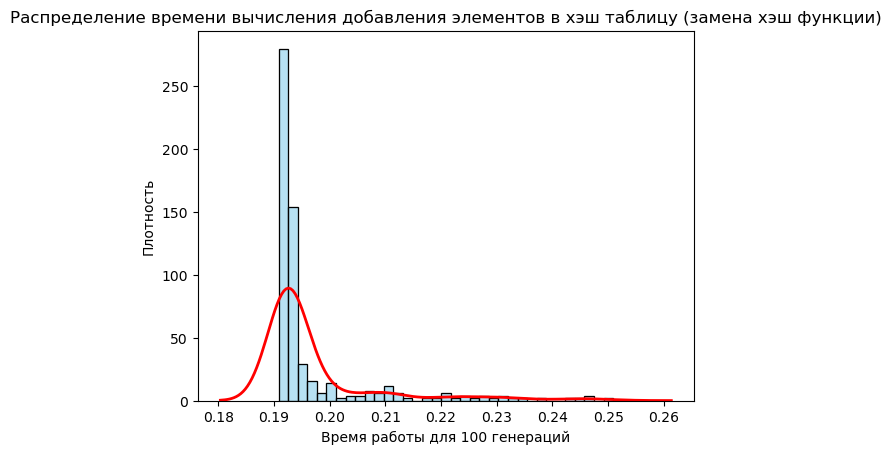

In [21]:
filtered = df[df.iloc[:,0] == "opt1"]

sns.histplot(
    data=filtered,
    x=filtered.iloc[:,1],
    bins="auto",
    stat="density",
    color="skyblue",
    alpha=0.6
)

sns.kdeplot(
    data=filtered,
    x=filtered.iloc[:,1],
    color="red",
    linewidth=2
)

plt.xlabel("Время работы для 100 генераций")
plt.ylabel("Плотность")
plt.title("Распределение времени вычисления добавления элементов в хэш таблицу (замена хэш функции)")
plt.show()

In [22]:
filtered.describe()

,1
count,300.000000
mean,0.196878
std,0.010895
min,0.190841
25%,0.191929
50%,0.192648
75%,0.194457
max,0.250897


In [24]:
mean = np.mean(filtered.iloc[:,1])
std = np.std(filtered.iloc[:,1], ddof=1)
n = len(filtered.iloc[:,1])

alpha = 0.05 
z = norm.ppf(1 - alpha/2)


lower = mean - z * std / np.sqrt(n)
upper = mean + z * std / np.sqrt(n)

print("Доверительный интервал:")
print(lower, upper)

Доверительный интервал:
0.19564508016310964 0.19811069983689036


### Среднее время работы версии с оптимизацией в виде замены хэш функции 0.20 (+- 0.01) секунд

### Посмотрим где теперь программа тратит больше всего времени

<img src="images_vlgrnd/Screenshot_20260421_231728.png" width="60%">


<img src="images_vlgrnd/Screenshot_20260421_231736.png" width="60%">

Видим, что больше всего времени тратиться в функции 
```c
int find_node(bucket_t* bucket, const uint32_t hash, const char* key)
```

Видим что большую часть времени функция проводит внутри себя. Возможно, это связано с тем, что для каждого узла в цепочке нужно сравнить хэш, а если хэш совпал, то затем и сам ключ. Однако можно ускорить - давайте будем сравнивать хэш одновременно для 8 ключей, а если ключей в некоторой ячейке больше 8, то будем уже сравнивать хэш по отдельности для каждого ключа. Для реализации этого напишем ассемберную вставку

## Оптимизация 2 - ускорение find_node

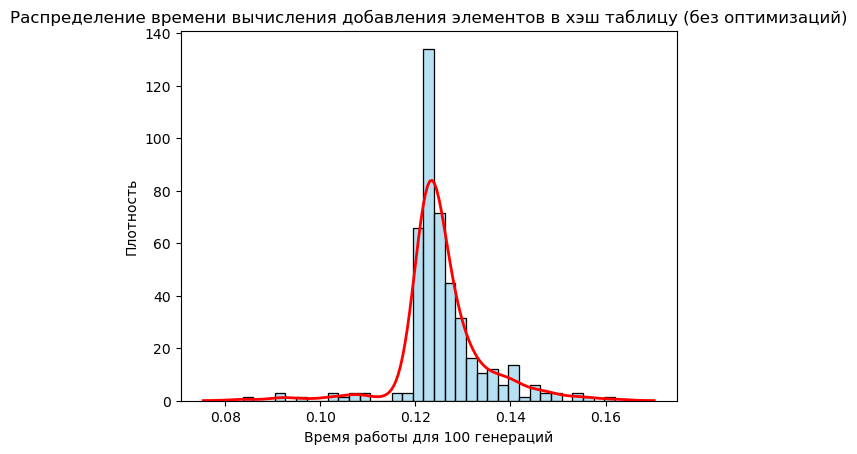

In [4]:
filtered = df[df.iloc[:,0] == "opt2"]

sns.histplot(
    data=filtered,
    x=filtered.iloc[:,1],
    bins="auto",
    stat="density",
    color="skyblue",
    alpha=0.6
)

sns.kdeplot(
    data=filtered,
    x=filtered.iloc[:,1],
    color="red",
    linewidth=2
)

plt.xlabel("Время работы для 100 генераций")
plt.ylabel("Плотность")
plt.title("Распределение времени вычисления добавления элементов в хэш таблицу (без оптимизаций)")
plt.show()

In [5]:
filtered.describe()

,1
count,300.000000
mean,0.125734
std,0.008656
min,0.083643
25%,0.122064
50%,0.123961
75%,0.127939
max,0.161950


In [6]:
mean = np.mean(filtered.iloc[:,1])
std = np.std(filtered.iloc[:,1], ddof=1)
n = len(filtered.iloc[:,1])

alpha = 0.05 
z = norm.ppf(1 - alpha/2)

lower = mean - z * std / np.sqrt(n)
upper = mean + z * std / np.sqrt(n)

print("Доверительный интервал:")
print(lower, upper)

Доверительный интервал:
0.1247541908313758 0.12671324783529084


### Среднее время работы версии с оптимизацией в виде замены хэш функции 0.126 (+- 0.009) секунд

### Посмотрим где теперь программа тратит больше всего времени

<img src="images_vlgrnd/Screenshot_20260421_232257.png" width="60%">


<img src="images_vlgrnd/Screenshot_20260421_232310.png" width="60%">

Видим, что больше всего времени по прежнему тратиться в функции 
```c
int find_node(bucket_t* bucket, const uint32_t hash, const char* key)
```

Но если посмотреть на эту функцию, можно заметить, что довольно-таки часто вызывается strcmp. Она работает довольно-таки медленно, так как написана для общего случая, но в нашем случае все строки размером 32 байта, и ложатся в ymm регистры, где можно сравнить данные регистры и получить данные о совпадении( также нам не нужно знать, какая строка длиннее или короче, нам нужно знать только совпадают строки или нет).


## Оптимизация 3 - my_strcmp()

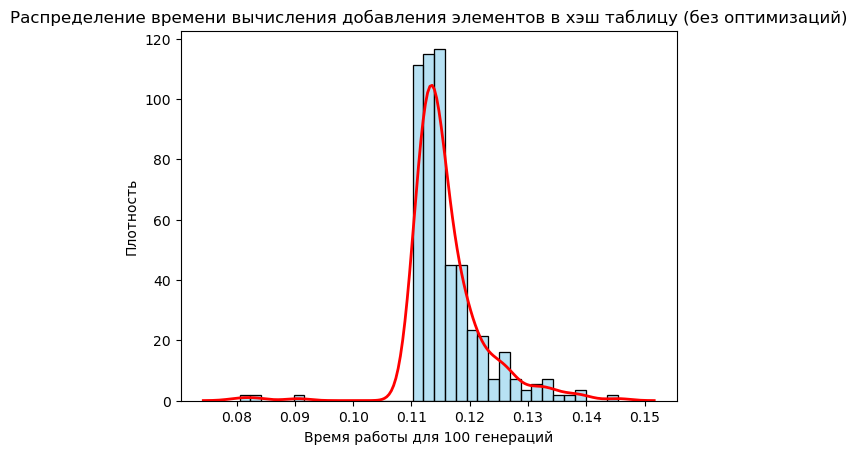

In [7]:
filtered = df[df.iloc[:,0] == "opt3"]

sns.histplot(
    data=filtered,
    x=filtered.iloc[:,1],
    bins="auto",
    stat="density",
    color="skyblue",
    alpha=0.6
)

sns.kdeplot(
    data=filtered,
    x=filtered.iloc[:,1],
    color="red",
    linewidth=2
)

plt.xlabel("Время работы для 100 генераций")
plt.ylabel("Плотность")
plt.title("Распределение времени вычисления добавления элементов в хэш таблицу (без оптимизаций)")
plt.show()

In [9]:
filtered.describe()

,1
count,300.000000
mean,0.115909
std,0.006483
min,0.080489
25%,0.112338
50%,0.114244
75%,0.118029
max,0.145446


In [10]:
mean = np.mean(filtered.iloc[:,1])
std = np.std(filtered.iloc[:,1], ddof=1)
n = len(filtered.iloc[:,1])

alpha = 0.05 
z = norm.ppf(1 - alpha/2)

lower = mean - z * std / np.sqrt(n)
upper = mean + z * std / np.sqrt(n)

print("Доверительный интервал:")
print(lower, upper)

Доверительный интервал:
0.11517539899724136 0.11664258900275859


### Среднее время работы версии с оптимизацией в виде замены хэш функции 0.116 (+- 0.006) секунд

# Сравнение всех реализаций


| Реализаций | Время | Относительное ускорение  | Абсолютное ускорение |  Относительное ускорение в долях / (кол-во асм кода) * 100% |
|-------------|-------------| -------------|  -------------|  -------------|
| Без оптимизаций    | 0.36 (+- 0.01)    | 1  | 1 |  - |
| Оптимизация хэша    | 0.20 (+- 0.01)    | 1.8 | 1.8  |  - |
| Оптимизация  find_node  | 0.126 (+- 0.009)    | 1.59 | 2.86 |  9.79 % |
| Замена  strcmp   | 0.116 (+- 0.006)    | 1.086 | 3.11 |  1.437 % |

Видим, что последняя оптимизация дала уже небольшое относительное ускорение  и хорошее абсолютное ускорение, следовательно стоит закончить оптимизировать хэш таблицы, так как дальнейшие оптмимизации усложнят понимание кода, но сильно код не ускорят.

# Доказательство отсутвия тротлинга при замерах

Каждый замер проводился 3 раза ( в каждом замере было 100 тестов), процесс был изолирован на 3(4, если нумеровать ядра с 1) ядре. Тактовая частота мной дополнительно не фксировалась, но была стабильна на протяжении замеров.

<img src="freq_img/Screenshot_20260418_201918.png" width="60%">


<img src="freq_img/Screenshot_20260418_201949.png" width="60%">


<img src="freq_img/Screenshot_20260418_202015.png" width="60%">


<img src="freq_img/Screenshot_20260418_212011.png" width="60%">


<img src="freq_img/Screenshot_20260418_212045.png" width="60%">


<img src="freq_img/Screenshot_20260418_212119.png" width="60%">


<img src="freq_img/Screenshot_20260418_213639.png" width="60%">


<img src="freq_img/Screenshot_20260418_213704.png" width="60%">


<img src="freq_img/Screenshot_20260418_214818.png" width="60%">


<img src="freq_img/Screenshot_20260418_214845.png" width="60%">


<img src="freq_img/Screenshot_20260418_214908.png" width="60%">


<img src="freq_img/Screenshot_20260418_221804.png" width="60%">